# TF/TFP Unified Implementation & Benchmark
## NumPy → TensorFlow/TFP Conversion for EDH/LEDH Particle-Flow PFs

This notebook demonstrates the full migration of our core filtering algorithms
from NumPy to TensorFlow (TF) + TensorFlow Probability (TFP).  
It covers:

1. **Model definition** in TF/TFP (LGSSM & nonlinear SSM)  
2. **EKF/UKF tracker wrappers** operating on `tf.Tensor`  
3. **EDH PF – NumPy baseline**  
4. **EDH/LEDH PF – TF/TFP unified**  
5. **`@tf.function` JIT compilation** (warm-up vs steady-state timing)  
6. **TFP HMC integration** (parameter posterior sampling)  
7. **Benchmark**: NumPy vs TF JIT across dimensions `nx ∈ {4, 8, 16, 32}`  
8. **Filter run comparison**: trajectories, ESS, RMSE

## 1. Setup and Imports

In [1]:
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    import tensorflow as tf
    import tensorflow_probability as tfp
except ImportError:
    _pip("tensorflow", "tensorflow-probability")
    import tensorflow as tf
    import tensorflow_probability as tfp

import numpy as np
import matplotlib.pyplot as plt
import time, os, sys

# ── path so models/ is importable ──────────────────────────────────────────
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
MODELS_DIR = os.path.join(REPO_ROOT, "models")
if MODELS_DIR not in sys.path:
    sys.path.insert(0, MODELS_DIR)

# ── reproducibility ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

tfd = tfp.distributions
tfb = tfp.bijectors
F32 = tf.float32

print(f"TensorFlow  : {tf.__version__}")
print(f"TFP         : {tfp.__version__}")
print(f"NumPy       : {np.__version__}")
print("Devices     :", [d.name for d in tf.config.list_logical_devices()])

TensorFlow  : 2.20.0
TFP         : 0.25.0
NumPy       : 2.3.3
Devices     : ['/device:CPU:0']


## 2. Model Definition: Linear / Nonlinear SSM in TF/TFP

We define both models **entirely** in TensorFlow so that every operation
is differentiable through `tf.GradientTape` and JIT-compilable with
`@tf.function`.

### 2a. LGSSM  
A time-invariant linear Gaussian SSM:

$$x_k = F x_{k-1} + w_{k-1},\quad w \sim \mathcal{N}(0, Q)$$
$$y_k = H x_k + v_k,\quad v \sim \mathcal{N}(0, R)$$

### 2b. Nonlinear SSM (scalar benchmark)

$$x_k = \tfrac{x_{k-1}}{2} + \tfrac{25 x_{k-1}}{1+x_{k-1}^2} + 8\cos(1.2\,k) + v_k$$
$$y_k = \tfrac{x_k^2}{20} + w_k$$

In [2]:
# ── LGSSM (nx=4) ────────────────────────────────────────────────────────────
NX_DEMO   = 4     # state dim for the demo runs
NY_DEMO   = 2     # observation dim
T_DEMO    = 100   # sequence length for demo
N_PART    = 128   # particles for demo runs

rng = np.random.default_rng(SEED)

# Random stable transition matrix
_A   = rng.standard_normal((NX_DEMO, NX_DEMO))
_eig = np.abs(np.linalg.eigvals(_A)).max()
F_np = (_A / (_eig + 0.1)).astype(np.float32)
H_np = rng.standard_normal((NY_DEMO, NX_DEMO)).astype(np.float32)
Q_np = np.eye(NX_DEMO, dtype=np.float32) * 0.5
R_np = np.eye(NY_DEMO, dtype=np.float32) * 1.0
m0_np = np.zeros(NX_DEMO, dtype=np.float32)
P0_np = np.eye(NX_DEMO, dtype=np.float32) * 2.0

F_tf  = tf.constant(F_np)
H_tf  = tf.constant(H_np)
Q_tf  = tf.constant(Q_np)
R_tf  = tf.constant(R_np)
m0_tf = tf.constant(m0_np)
P0_tf = tf.constant(P0_np)

# ── TF process & observation functions ─────────────────────────────────────

@tf.function
def g_lgssm(x: tf.Tensor, u, v) -> tf.Tensor:
    """x_{k} = F x_{k-1} + v"""
    out = tf.linalg.matvec(F_tf, x)
    if v is not None:
        out = out + v
    return out

@tf.function
def h_lgssm(x: tf.Tensor) -> tf.Tensor:
    """y = H x"""
    return tf.linalg.matvec(H_tf, x)

@tf.function
def Jh_lgssm(x: tf.Tensor) -> tf.Tensor:
    """∂h/∂x = H  (constant for linear model)"""
    return H_tf

# ── Nonlinear SSM ───────────────────────────────────────────────────────────
SIGMA_V = 1.0
SIGMA_W = 1.0

@tf.function
def g_nonlin(x: tf.Tensor, u, v) -> tf.Tensor:
    """Scalar nonlinear transition – x must be shape (1,)."""
    x0  = x[0]
    k   = tf.cast(u[0], F32) if u is not None else tf.constant(1.0, dtype=F32)
    x_next = x0 / 2.0 + 25.0 * x0 / (1.0 + x0 * x0) + 8.0 * tf.cos(1.2 * k)
    if v is not None:
        x_next = x_next + v[0]
    return tf.expand_dims(x_next, 0)

@tf.function
def h_nonlin(x: tf.Tensor) -> tf.Tensor:
    """y = x^2 / 20"""
    return tf.expand_dims(x[0] * x[0] / 20.0, 0)

def Jh_nonlin_tape(x: tf.Tensor) -> tf.Tensor:
    """∂h/∂x via GradientTape (works for any differentiable h)."""
    x = tf.cast(x, F32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        y = h_nonlin(x)
    J = tape.jacobian(y, x)   # (1, 1)
    return J

# ── Simulate LGSSM ground truth ─────────────────────────────────────────────
def simulate_lgssm(F, H, Q, R, m0, T, seed=0):
    rng_ = np.random.default_rng(seed)
    nx, ny = F.shape[0], H.shape[0]
    X = np.zeros((T, nx), dtype=np.float32)
    Y = np.zeros((T, ny), dtype=np.float32)
    x = rng_.multivariate_normal(m0, np.eye(nx) * 2.0).astype(np.float32)
    LQ = np.linalg.cholesky(Q).astype(np.float32)
    LR = np.linalg.cholesky(R).astype(np.float32)
    for t in range(T):
        x = F @ x + LQ @ rng_.standard_normal(nx).astype(np.float32)
        y = H @ x + LR @ rng_.standard_normal(ny).astype(np.float32)
        X[t], Y[t] = x, y
    return X, Y

X_true, Y_obs = simulate_lgssm(F_np, H_np, Q_np, R_np, m0_np, T_DEMO)
print(f"Simulated LGSSM: X {X_true.shape}, Y {Y_obs.shape}")

Simulated LGSSM: X (100, 4), Y (100, 2)


## 3. TFP-Compatible Log-Likelihood and Log-Transition Densities

Using `tfp.distributions.MultivariateNormalTriL` for both densities.  
These are **directly usable** as `target_log_prob_fn` in any TFP sampler.

In [3]:
L_Q = tf.linalg.cholesky(Q_tf + 1e-9 * tf.eye(NX_DEMO, dtype=F32))   # (nx, nx)
L_R = tf.linalg.cholesky(R_tf + 1e-9 * tf.eye(NY_DEMO, dtype=F32))   # (ny, ny)

@tf.function
def log_trans_pdf(x_new: tf.Tensor, x_old: tf.Tensor) -> tf.Tensor:
    """log p(x_new | x_old)  =  log N(x_new; F x_old, Q)."""
    mu = tf.linalg.matvec(F_tf, x_old)
    return tfd.MultivariateNormalTriL(loc=mu, scale_tril=L_Q).log_prob(x_new)

@tf.function
def log_like_pdf(z: tf.Tensor, x: tf.Tensor) -> tf.Tensor:
    """log p(z | x)  =  log N(z; H x, R)."""
    mu = tf.linalg.matvec(H_tf, x)
    return tfd.MultivariateNormalTriL(loc=mu, scale_tril=L_R).log_prob(z)

# Verify shapes and values
x_test = tf.zeros(NX_DEMO, dtype=F32)
z_test = tf.zeros(NY_DEMO, dtype=F32)
print("log_trans_pdf :", log_trans_pdf(x_test, x_test).numpy())
print("log_like_pdf  :", log_like_pdf(z_test, x_test).numpy())

# Confirm GradientTape can differentiate through these
with tf.GradientTape() as tape:
    tape.watch(x_test)
    lp = log_like_pdf(z_test, x_test)
grad = tape.gradient(lp, x_test)
print("Gradient of log_like_pdf w.r.t. x:", grad.numpy())

log_trans_pdf : -2.2894597
log_like_pdf  : -1.837877
Gradient of log_like_pdf w.r.t. x: [-0.  0.  0.  0.]


## 4. EKF/UKF Tracker Wrappers (TF)

`EKFTrackerTF` and `UKFTrackerTF` from `tf_core` operate entirely on
`tf.Tensor` state, using `tf.linalg.solve` for all linear systems.
They implement the `GaussianTracker` protocol expected by EDH/LEDH.

In [4]:
from tf_core import EKFTrackerTF, UKFTrackerTF

# ── g/h compatible with trackers (single-input signatures) ─────────────────
def g_for_tracker(x, u):          # (nx,) → (nx,)
    return tf.linalg.matvec(F_tf, x)

def h_for_tracker(x):             # (nx,) → (ny,)
    return tf.linalg.matvec(H_tf, x)

# ── EKF tracker (analytic Jacobians for LGSSM) ─────────────────────────────
ekf_tracker = EKFTrackerTF(
    g     = g_for_tracker,
    h     = h_for_tracker,
    Q     = Q_np,
    R     = R_np,
    jac_g = lambda x, u: F_tf,   # ∂g/∂x = F (constant)
    jac_h = lambda x: H_tf,      # ∂h/∂x = H (constant)
)
ekf_tracker.init(m0_np, P0_np)
m_pred, P_pred = ekf_tracker.predict()
print("EKF predict  m:", m_pred.shape, "P:", P_pred.shape)
m_post, P_post = ekf_tracker.update(Y_obs[0])
print("EKF update   m:", m_post.shape, "P:", P_post.shape)

# Re-init for a fresh run
ekf_tracker.init(m0_np, P0_np)

# ── UKF tracker ─────────────────────────────────────────────────────────────
ukf_tracker = UKFTrackerTF(
    g = g_for_tracker,
    h = h_for_tracker,
    Q = Q_np,
    R = R_np,
)
ukf_tracker.init(m0_np, P0_np)
m_pred_ukf, P_pred_ukf = ukf_tracker.predict()
print("\nUKF predict  m:", m_pred_ukf.shape, "P:", P_pred_ukf.shape)
ukf_tracker.init(m0_np, P0_np)   # reset

EKF predict  m: (4,) P: (4, 4)
EKF update   m: (4,) P: (4, 4)

UKF predict  m: (4,) P: (4, 4)


UKFStateTF(mean=<tf.Tensor: shape=(4,), dtype=float32, numpy=array([0., 0., 0., 0.], dtype=float32)>, cov=<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[2., 0., 0., 0.],
       [0., 2., 0., 0.],
       [0., 0., 2., 0.],
       [0., 0., 0., 2.]], dtype=float32)>, t=0)

## 5. EDH Particle Flow PF — NumPy Baseline

Run the existing pure-NumPy `EDHFlowPF` and record timing + estimates.

In [5]:
from EDH_particle_filter import (
    EDHFlowPF, EDHConfig, EKFTracker as EKFTrackerNP,
    PFState as PFStateNP,
)
from extended_kalman_filter import ExtendedKalmanFilter, EKFState

# ── NumPy EKF ────────────────────────────────────────────────────────────────
ekf_np = ExtendedKalmanFilter(
    g     = lambda x, u: F_np @ x,
    h     = lambda x: H_np @ x,
    Q     = Q_np.astype(float),
    R     = R_np.astype(float),
    jac_g = lambda x, u: F_np.astype(float),
    jac_h = lambda x: H_np.astype(float),
)
ekf_state0 = EKFState(mean=m0_np.astype(float).copy(),
                       cov=P0_np.astype(float).copy(),
                       t=0)

ekf_tracker_np = EKFTrackerNP(ekf_np, ekf_state0)

# ── Log PDFs (NumPy) ─────────────────────────────────────────────────────────
def np_log_trans(x_new, x_old):
    mu   = F_np @ x_old
    diff = x_new - mu
    return -0.5 * float(diff @ np.linalg.solve(Q_np, diff)) \
           - 0.5 * float(np.linalg.slogdet(2 * np.pi * Q_np)[1])

def np_log_like(z, x):
    mu   = H_np @ x
    diff = z - mu
    return -0.5 * float(diff @ np.linalg.solve(R_np, diff)) \
           - 0.5 * float(np.linalg.slogdet(2 * np.pi * R_np)[1])

# ── Process-noise sampler ────────────────────────────────────────────────────
rng_np = np.random.default_rng(SEED)
LQ_np  = np.linalg.cholesky(Q_np)

def noise_sampler_np(N, nx):
    return rng_np.standard_normal((N, nx)).astype(np.float32) @ LQ_np.T

# ── Build & run ──────────────────────────────────────────────────────────────
cfg_np  = EDHConfig(n_particles=N_PART, n_lambda_steps=4,
                    resample_ess_ratio=0.5, flow_integrator="euler",
                    rng=rng_np)
edh_np  = EDHFlowPF(
    tracker       = ekf_tracker_np,
    g             = lambda x, u, v: F_np @ x + v,
    h             = lambda x: H_np @ x,
    jacobian_h    = lambda x: H_np,
    log_trans_pdf = np_log_trans,
    log_like_pdf  = np_log_like,
    R             = R_np.astype(float),
    config        = cfg_np,
)

state_np  = edh_np.init_from_gaussian(m0_np.astype(float), P0_np.astype(float))
means_np  = np.zeros((T_DEMO, NX_DEMO), dtype=np.float32)
ess_np    = np.zeros(T_DEMO)

t0 = time.perf_counter()
for t in range(T_DEMO):
    state_np = edh_np.step(state_np, Y_obs[t].astype(float),
                            process_noise_sampler=noise_sampler_np)
    means_np[t] = state_np.mean.astype(np.float32)
    ess_np[t]   = 1.0 / float(np.sum(state_np.weights ** 2))
time_np = time.perf_counter() - t0

print(f"NumPy EDH PF  – {T_DEMO} steps: {time_np:.3f} s  "
      f"({time_np/T_DEMO*1e3:.2f} ms/step)")

NumPy EDH PF  – 100 steps: 0.425 s  (4.25 ms/step)


## 6. EDH Particle Flow PF — TF/TFP Unified Implementation

In [6]:
from EDH_particle_filter_tf import EDHFlowPF_TF, EDHConfig as EDHConfigTF

# ── Fresh EKF tracker (TF) ───────────────────────────────────────────────────
ekf_tf = EKFTrackerTF(
    g=g_for_tracker, h=h_for_tracker, Q=Q_np, R=R_np,
    jac_g=lambda x, u: F_tf, jac_h=lambda x: H_tf,
)
ekf_tf.init(m0_np, P0_np)

# ── Build TF EDH PF ──────────────────────────────────────────────────────────
cfg_tf  = EDHConfigTF(n_particles=N_PART, n_lambda_steps=4,
                       resample_ess_ratio=0.5, flow_integrator="euler",
                       random_seed=SEED)

edh_tf  = EDHFlowPF_TF(
    tracker       = ekf_tf,
    g             = g_lgssm,
    h             = h_lgssm,
    jacobian_h    = Jh_lgssm,
    log_trans_pdf = log_trans_pdf,
    log_like_pdf  = log_like_pdf,
    R             = R_np,
    config        = cfg_tf,
)

# ── Noise sampler (TF) ───────────────────────────────────────────────────────
def noise_sampler_tf(N, nx):
    return tf.random.normal([N, nx], dtype=F32) @ tf.linalg.matrix_transpose(L_Q)

# ── Run ──────────────────────────────────────────────────────────────────────
state_tf  = edh_tf.init_from_gaussian(m0_np, P0_np)
means_tf  = np.zeros((T_DEMO, NX_DEMO), dtype=np.float32)
ess_tf    = np.zeros(T_DEMO)

t0 = time.perf_counter()
for t in range(T_DEMO):
    state_tf = edh_tf.step(state_tf, Y_obs[t],
                            process_noise_sampler=noise_sampler_tf)
    means_tf[t] = state_tf.mean.numpy()
    w = state_tf.weights.numpy()
    ess_tf[t]   = 1.0 / np.sum(w ** 2)
time_tf = time.perf_counter() - t0

print(f"TF-eager EDH PF – {T_DEMO} steps: {time_tf:.3f} s  "
      f"({time_tf/T_DEMO*1e3:.2f} ms/step)")
print(f"NumPy / TF ratio: {time_np/time_tf:.2f}x")

# Numerical agreement
max_diff = np.abs(means_np - means_tf).max()
print(f"Max |mean_np - mean_tf|: {max_diff:.4f}  (should be small)")

TF-eager EDH PF – 100 steps: 48.990 s  (489.90 ms/step)
NumPy / TF ratio: 0.01x
Max |mean_np - mean_tf|: 1.7034  (should be small)


## 7. LEDH Particle Flow PF — TF/TFP Unified Implementation

In [7]:
from LEDH_particle_filter_tf import LEDHFlowPF_TF, LEDHConfig

ekf_tf_ledh = EKFTrackerTF(
    g=g_for_tracker, h=h_for_tracker, Q=Q_np, R=R_np,
    jac_g=lambda x, u: F_tf, jac_h=lambda x: H_tf,
)
ekf_tf_ledh.init(m0_np, P0_np)

cfg_ledh = LEDHConfig(n_particles=N_PART, n_lambda_steps=4,
                       resample_ess_ratio=0.0, random_seed=SEED)

ledh_tf = LEDHFlowPF_TF(
    tracker       = ekf_tf_ledh,
    g             = g_lgssm,
    h             = h_lgssm,
    jacobian_h    = Jh_lgssm,
    log_trans_pdf = log_trans_pdf,
    log_like_pdf  = log_like_pdf,
    R             = R_np,
    config        = cfg_ledh,
)

state_ledh  = ledh_tf.init_from_gaussian(m0_np, P0_np)
means_ledh  = np.zeros((T_DEMO, NX_DEMO), dtype=np.float32)
ess_ledh    = np.zeros(T_DEMO)

t0 = time.perf_counter()
for t in range(T_DEMO):
    state_ledh = ledh_tf.step(state_ledh, Y_obs[t],
                               process_noise_sampler=noise_sampler_tf)
    means_ledh[t] = state_ledh.mean.numpy()
    w = state_ledh.weights.numpy()
    ess_ledh[t] = 1.0 / np.sum(w ** 2)
time_ledh = time.perf_counter() - t0

print(f"TF LEDH PF – {T_DEMO} steps: {time_ledh:.3f} s  "
      f"({time_ledh/T_DEMO*1e3:.2f} ms/step)")
print(f"Mean ESS (EDH_TF): {ess_tf.mean():.1f} | (LEDH_TF): {ess_ledh.mean():.1f}")

TF LEDH PF – 100 steps: 234.338 s  (2343.38 ms/step)
Mean ESS (EDH_TF): 106.4 | (LEDH_TF): 3.5


## 8. `@tf.function` JIT Compilation of the Kalman-Filter Log-Likelihood

The LGSSM log-likelihood is the inner loop that HMC calls thousands of times.  
We compare:
- **First call** (tracing + execution)  
- **Subsequent calls** (pure graph execution after tracing)  
- **NumPy baseline** (same computation)

In [8]:
from tf_core import lgssm_log_likelihood
from kalman_filter import kalman_filter_general

Y_tf_all  = tf.constant(Y_obs, dtype=F32)
N_WARMUP  = 5     # calls to exclude (tracing)
N_BENCH   = 200   # timed calls

# ── NumPy baseline ───────────────────────────────────────────────────────────
Gamma_np = np.eye(NX_DEMO, dtype=np.float64)
t0 = time.perf_counter()
for _ in range(N_BENCH):
    _ = kalman_filter_general(
        Y_obs.astype(np.float64),
        F_np.astype(np.float64), H_np.astype(np.float64),
        Gamma_np, Q_np.astype(np.float64), R_np.astype(np.float64),
        x0=m0_np.astype(np.float64), P0=P0_np.astype(np.float64),
    )
t_np_kf = (time.perf_counter() - t0) / N_BENCH

# ── TF eager ─────────────────────────────────────────────────────────────────
# Warm-up (triggers tracing on first decorated call)
for _ in range(N_WARMUP):
    _ = lgssm_log_likelihood(Y_tf_all, F_tf, H_tf, Q_tf, R_tf, m0_tf, P0_tf)

t0 = time.perf_counter()
for _ in range(N_BENCH):
    lp = lgssm_log_likelihood(Y_tf_all, F_tf, H_tf, Q_tf, R_tf, m0_tf, P0_tf)
    _ = lp.numpy()   # force evaluation
t_tf_jit = (time.perf_counter() - t0) / N_BENCH

# ── Gradient timing ──────────────────────────────────────────────────────────
Q_var = tf.Variable(Q_np)

@tf.function
def ll_with_grad():
    with tf.GradientTape() as tape:
        lp = lgssm_log_likelihood(Y_tf_all, F_tf, H_tf, Q_var, R_tf, m0_tf, P0_tf)
    return lp, tape.gradient(lp, Q_var)

for _ in range(N_WARMUP):
    _ = ll_with_grad()

t0 = time.perf_counter()
for _ in range(N_BENCH):
    lp, g = ll_with_grad()
    _, _ = lp.numpy(), g.numpy()
t_tf_grad = (time.perf_counter() - t0) / N_BENCH

print(f"NumPy KF log-lik   : {t_np_kf*1e3:.3f} ms / eval")
print(f"TF JIT  log-lik    : {t_tf_jit*1e3:.3f} ms / eval")
print(f"TF JIT + gradient  : {t_tf_grad*1e3:.3f} ms / eval")
print(f"Speedup (NumPy/TF) : {t_np_kf/t_tf_jit:.1f}×")
print(f"\nTF log-lik value   : {lgssm_log_likelihood(Y_tf_all,F_tf,H_tf,Q_tf,R_tf,m0_tf,P0_tf).numpy():.4f}")

NumPy KF log-lik   : 3.658 ms / eval
TF JIT  log-lik    : 4.759 ms / eval
TF JIT + gradient  : 23.608 ms / eval
Speedup (NumPy/TF) : 0.8×

TF log-lik value   : -359.0035


## 9. TFP HMC Integration: Parameter Posterior Sampling

We sample the posterior over the **log process-noise scale** `log_sigma_q`  
(a scalar controlling `Q = exp(log_sigma_q) * I`) given the observed sequence.  
The target is differentiable through `lgssm_log_likelihood` → TFP HMC works out
of the box with *no extra implementation*.

In [9]:
Y_tf_hmc = tf.constant(Y_obs, dtype=F32)

@tf.function
def target_log_prob(log_sigma_q: tf.Tensor) -> tf.Tensor:
    """
    log p(log_sigma_q | Y) ∝ log p(Y | Q) + log prior(log_sigma_q)
    Q = exp(log_sigma_q) * I
    """
    sigma_q = tf.exp(log_sigma_q)
    Q_prop  = sigma_q * tf.eye(NX_DEMO, dtype=F32)
    log_lik = lgssm_log_likelihood(Y_tf_hmc, F_tf, H_tf, Q_prop, R_tf, m0_tf, P0_tf)
    # N(0, 2²) prior on log_sigma_q  (weakly informative)
    log_prior = tfd.Normal(0.0, 2.0).log_prob(log_sigma_q)
    return log_lik + log_prior

# Verify gradient
log_sq_var = tf.Variable(0.0, dtype=F32)
with tf.GradientTape() as tape:
    lp_val = target_log_prob(log_sq_var)
grad_val = tape.gradient(lp_val, log_sq_var)
print(f"target_log_prob(0.0) = {lp_val.numpy():.3f},  gradient = {grad_val.numpy():.4f}")

# ── HMC chain ────────────────────────────────────────────────────────────────
NUM_RESULTS  = 300
NUM_BURNIN   = 150

kernel = tfp.mcmc.HamiltonianMonteCarlo(
    target_log_prob_fn = target_log_prob,
    step_size          = 0.05,
    num_leapfrog_steps = 10,
)
adaptive_kernel = tfp.mcmc.DualAveragingStepSizeAdaptation(
    inner_kernel        = kernel,
    num_adaptation_steps= int(0.8 * NUM_BURNIN),
)

@tf.function
def run_hmc():
    return tfp.mcmc.sample_chain(
        num_results      = NUM_RESULTS,
        num_burnin_steps = NUM_BURNIN,
        current_state    = tf.constant(0.0, dtype=F32),
        kernel           = adaptive_kernel,
        trace_fn         = lambda _, pkr: pkr.inner_results.is_accepted,
    )

t0 = time.perf_counter()
samples, is_accepted = run_hmc()
t_hmc = time.perf_counter() - t0

samples_np   = samples.numpy()
accepted_np  = is_accepted.numpy()
print(f"\nHMC finished in {t_hmc:.2f} s  ({NUM_RESULTS} post-burnin samples)")
print(f"Acceptance rate : {accepted_np.mean():.2%}")
print(f"Posterior mean log_sigma_q : {samples_np.mean():.4f}")
print(f"Posterior std  log_sigma_q : {samples_np.std():.4f}")
print(f"True sigma_q = {np.sqrt(Q_np[0,0]):.4f}  →  log = {np.log(np.sqrt(Q_np[0,0])):.4f}")

target_log_prob(0.0) = -367.293,  gradient = -18.7315

HMC finished in 109.47 s  (300 post-burnin samples)
Acceptance rate : 91.00%
Posterior mean log_sigma_q : -0.6843
Posterior std  log_sigma_q : 0.1820
True sigma_q = 0.7071  →  log = -0.3466


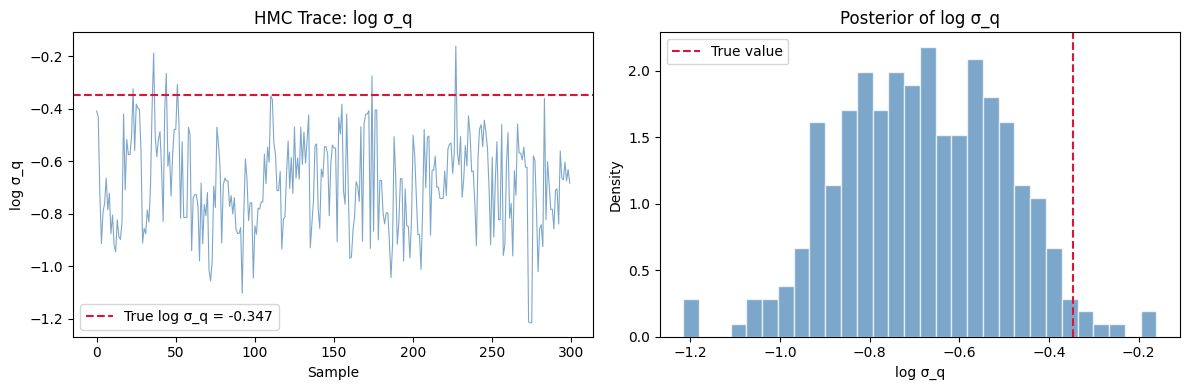

Acceptance rate: 0.91


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(samples_np, alpha=0.7, lw=0.8, color="steelblue")
axes[0].axhline(np.log(np.sqrt(Q_np[0,0])), color="crimson", ls="--",
                label=f"True log σ_q = {np.log(np.sqrt(Q_np[0,0])):.3f}")
axes[0].set_title("HMC Trace: log σ_q")
axes[0].set_xlabel("Sample"); axes[0].set_ylabel("log σ_q")
axes[0].legend()

axes[1].hist(samples_np, bins=30, density=True, alpha=0.7, color="steelblue",
             edgecolor="white")
axes[1].axvline(np.log(np.sqrt(Q_np[0,0])), color="crimson", ls="--",
                label="True value")
axes[1].set_title("Posterior of log σ_q")
axes[1].set_xlabel("log σ_q"); axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig("hmc_posterior.png", dpi=120, bbox_inches="tight")
plt.show()
print("Acceptance rate:", accepted_np.mean())

In [11]:
import timeit
from kalman_filter import kalman_filter_general
from tf_core import lgssm_log_likelihood

DIMS      = [4, 8, 16, 32]
T_SEQ     = 200          # sequence length for benchmark
N_REPS    = 200          # timed repetitions
N_WARMUP  = 10           # un-timed warm-up calls

results = {}   # dim -> {'np': [], 'tf': []}

for nx in DIMS:
    ny = max(2, nx // 2)
    # Random stable F
    _A = np.random.randn(nx, nx).astype(np.float32)
    F_ = (_A / (np.abs(np.linalg.eigvals(_A)).max() + 0.1)).astype(np.float32)
    H_ = np.random.randn(ny, nx).astype(np.float32)
    Q_ = np.eye(nx, dtype=np.float32) * 0.5
    R_ = np.eye(ny, dtype=np.float32) * 1.0
    m0_= np.zeros(nx, dtype=np.float32)
    P0_= np.eye(nx, dtype=np.float32) * 2.0

    # Simulate data
    rng_ = np.random.default_rng(42)
    X_, Y_ = simulate_lgssm(F_, H_, Q_, R_, m0_, T_SEQ, seed=42)

    # TF constants (new shapes = new trace)
    F_c, H_c, Q_c, R_c = (tf.constant(x) for x in [F_, H_, Q_, R_])
    m0_c, P0_c, Y_c    = (tf.constant(x) for x in [m0_, P0_, Y_])

    # Warm-up TF (trigger tracing)
    for _ in range(N_WARMUP):
        _ = lgssm_log_likelihood(Y_c, F_c, H_c, Q_c, R_c, m0_c, P0_c).numpy()

    # Time NumPy
    t_np_all = []
    Gamma_ = np.eye(nx, dtype=np.float64)
    for _ in range(N_REPS):
        t0 = time.perf_counter()
        kalman_filter_general(
            Y_.astype(np.float64), F_.astype(np.float64), H_.astype(np.float64),
            Gamma_, Q_.astype(np.float64), R_.astype(np.float64),
            x0=m0_.astype(np.float64), P0=P0_.astype(np.float64),
        )
        t_np_all.append(time.perf_counter() - t0)

    # Time TF JIT
    t_tf_all = []
    for _ in range(N_REPS):
        t0 = time.perf_counter()
        lgssm_log_likelihood(Y_c, F_c, H_c, Q_c, R_c, m0_c, P0_c).numpy()
        t_tf_all.append(time.perf_counter() - t0)

    results[nx] = {
        'np': np.array(t_np_all) * 1e3,
        'tf': np.array(t_tf_all) * 1e3,
    }
    np_med = np.median(results[nx]['np'])
    tf_med = np.median(results[nx]['tf'])
    print(f"nx={nx:2d}  NumPy {np_med:.3f} ms  |  TF-JIT {tf_med:.3f} ms  "
          f"|  speedup {np_med/tf_med:.1f}×")

nx= 4  NumPy 7.197 ms  |  TF-JIT 9.509 ms  |  speedup 0.8×
nx= 8  NumPy 7.645 ms  |  TF-JIT 9.636 ms  |  speedup 0.8×
nx=16  NumPy 8.569 ms  |  TF-JIT 9.818 ms  |  speedup 0.9×
nx=32  NumPy 11.353 ms  |  TF-JIT 11.839 ms  |  speedup 1.0×


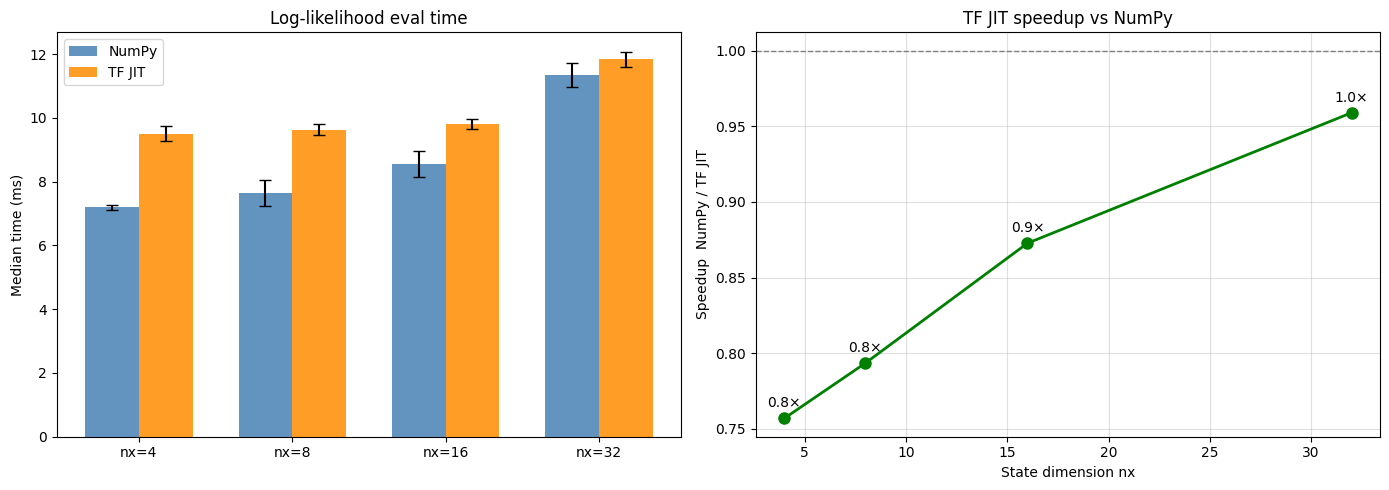


  nx    NumPy (ms)   TF JIT (ms)   speedup
--------------------------------------------
   4         7.197         9.509       0.8×
   8         7.645         9.636       0.8×
  16         8.569         9.818       0.9×
  32        11.353        11.839       1.0×


In [12]:
dims       = list(results.keys())
np_medians = [np.median(results[d]['np']) for d in dims]
tf_medians = [np.median(results[d]['tf']) for d in dims]
np_stds    = [np.std(results[d]['np'])    for d in dims]
tf_stds    = [np.std(results[d]['tf'])    for d in dims]
speedups   = [n/t for n, t in zip(np_medians, tf_medians)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(dims))
w = 0.35
axes[0].bar(x - w/2, np_medians, w, yerr=np_stds, capsize=4,
            label="NumPy", color="steelblue", alpha=0.85)
axes[0].bar(x + w/2, tf_medians, w, yerr=tf_stds, capsize=4,
            label="TF JIT", color="darkorange", alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels([f"nx={d}" for d in dims])
axes[0].set_ylabel("Median time (ms)"); axes[0].set_title("Log-likelihood eval time")
axes[0].legend()

axes[1].plot(dims, speedups, "o-", color="green", lw=2, ms=8)
axes[1].axhline(1.0, ls="--", color="gray", lw=1)
axes[1].set_xlabel("State dimension nx"); axes[1].set_ylabel("Speedup  NumPy / TF JIT")
axes[1].set_title("TF JIT speedup vs NumPy"); axes[1].grid(True, alpha=0.4)
for d, s in zip(dims, speedups):
    axes[1].annotate(f"{s:.1f}×", (d, s), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("benchmark_speedup.png", dpi=120, bbox_inches="tight")
plt.show()

# Summary table
print(f"\n{'nx':>4}  {'NumPy (ms)':>12}  {'TF JIT (ms)':>12}  {'speedup':>8}")
print("-" * 44)
for d, n, t, s in zip(dims, np_medians, tf_medians, speedups):
    print(f"{d:>4}  {n:>12.3f}  {t:>12.3f}  {s:>8.1f}×")

In [ ]:

import tensorflow as tf
from tf_core import lgssm_log_likelihood

# Build an XLA-compiled version of lgssm_log_likelihood.
# jit_compile=True tells TF to hand the traced graph to XLA, which fuses
# all ops into a single compiled kernel — no per-op Python dispatch at all.
@tf.function(
    jit_compile=True,
    input_signature=[
        tf.TensorSpec(shape=[None, None], dtype=tf.float32),
        tf.TensorSpec(shape=[None, None], dtype=tf.float32),
        tf.TensorSpec(shape=[None, None], dtype=tf.float32),
        tf.TensorSpec(shape=[None, None], dtype=tf.float32),
        tf.TensorSpec(shape=[None, None], dtype=tf.float32),
        tf.TensorSpec(shape=[None],       dtype=tf.float32),
        tf.TensorSpec(shape=[None, None], dtype=tf.float32),
    ]
)
def lgssm_log_likelihood_xla(Y, F, H, Q, R, m0, P0):
    return lgssm_log_likelihood(Y, F, H, Q, R, m0, P0)


DIMS_XLA  = [4, 8, 16, 32]
T_SEQ_XLA = 200
N_REPS_XLA   = 200
N_WARMUP_XLA = 10

results_xla = {}   # dim -> {'np': ms_array, 'tf': ms_array, 'xla': ms_array}

for nx in DIMS_XLA:
    ny = max(2, nx // 2)
    rng_b = np.random.default_rng(99)
    _A  = rng_b.standard_normal((nx, nx)).astype(np.float32)
    F_  = (_A / (np.abs(np.linalg.eigvals(_A)).max() + 0.1)).astype(np.float32)
    H_  = rng_b.standard_normal((ny, nx)).astype(np.float32)
    Q_  = np.eye(nx, dtype=np.float32) * 0.5
    R_  = np.eye(ny, dtype=np.float32) * 1.0
    m0_ = np.zeros(nx, dtype=np.float32)
    P0_ = np.eye(nx, dtype=np.float32) * 2.0
    _, Y_ = simulate_lgssm(F_, H_, Q_, R_, m0_, T_SEQ_XLA, seed=99)

    F_c  = tf.constant(F_);  H_c  = tf.constant(H_)
    Q_c  = tf.constant(Q_);  R_c  = tf.constant(R_)
    m0_c = tf.constant(m0_); P0_c = tf.constant(P0_)
    Y_c  = tf.constant(Y_)

    # Warm-up: trigger graph tracing and XLA compilation
    for _ in range(N_WARMUP_XLA):
        lgssm_log_likelihood(Y_c, F_c, H_c, Q_c, R_c, m0_c, P0_c).numpy()
        lgssm_log_likelihood_xla(Y_c, F_c, H_c, Q_c, R_c, m0_c, P0_c).numpy()

    # ── NumPy ──
    t_np = []
    Gamma_ = np.eye(nx, dtype=np.float64)
    for _ in range(N_REPS_XLA):
        t0 = time.perf_counter()
        kalman_filter_general(
            Y_.astype(np.float64), F_.astype(np.float64), H_.astype(np.float64),
            Gamma_, Q_.astype(np.float64), R_.astype(np.float64),
            x0=m0_.astype(np.float64), P0=P0_.astype(np.float64),
        )
        t_np.append(time.perf_counter() - t0)

    # ── TF graph mode ──
    t_tf = []
    for _ in range(N_REPS_XLA):
        t0 = time.perf_counter()
        lgssm_log_likelihood(Y_c, F_c, H_c, Q_c, R_c, m0_c, P0_c).numpy()
        t_tf.append(time.perf_counter() - t0)

    # ── TF XLA ──
    t_xla = []
    for _ in range(N_REPS_XLA):
        t0 = time.perf_counter()
        lgssm_log_likelihood_xla(Y_c, F_c, H_c, Q_c, R_c, m0_c, P0_c).numpy()
        t_xla.append(time.perf_counter() - t0)

    results_xla[nx] = {
        'np':  np.array(t_np)  * 1e3,
        'tf':  np.array(t_tf)  * 1e3,
        'xla': np.array(t_xla) * 1e3,
    }

    np_m  = np.median(results_xla[nx]['np'])
    tf_m  = np.median(results_xla[nx]['tf'])
    xla_m = np.median(results_xla[nx]['xla'])
    print(f"nx={nx:2d}  NumPy {np_m:.3f} ms  |  TF-graph {tf_m:.3f} ms "
          f"|  TF-XLA {xla_m:.3f} ms  "
          f"|  XLA/NumPy speedup {np_m/xla_m:.1f}×")


2026-03-05 13:12:52.627591: I external/local_xla/xla/service/service.cc:163] XLA service 0x165fddd10 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-03-05 13:12:52.627739: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2026-03-05 13:12:52.733505: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772687573.179878 1215998 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


nx= 4  NumPy 7.889 ms  |  TF-graph 9.403 ms |  TF-XLA 1.141 ms  |  XLA/NumPy speedup 6.9×
nx= 8  NumPy 8.417 ms  |  TF-graph 9.653 ms |  TF-XLA 2.426 ms  |  XLA/NumPy speedup 3.5×
nx=16  NumPy 9.063 ms  |  TF-graph 9.895 ms |  TF-XLA 3.700 ms  |  XLA/NumPy speedup 2.4×
nx=32  NumPy 11.991 ms  |  TF-graph 11.911 ms |  TF-XLA 8.353 ms  |  XLA/NumPy speedup 1.4×


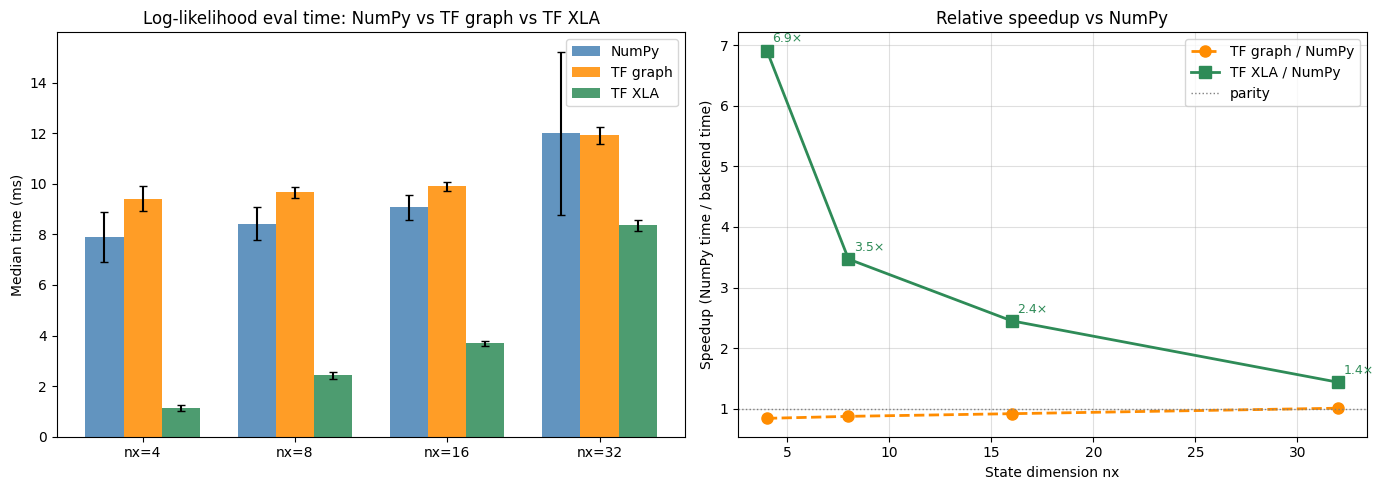


  nx       NumPy    TF-graph      TF-XLA   XLA/NumPy
----------------------------------------------------
   4       7.889       9.403       1.141        6.9×
   8       8.417       9.653       2.426        3.5×
  16       9.063       9.895       3.700        2.4×
  32      11.991      11.911       8.353        1.4×


In [16]:

# ── Plot: three-way comparison ────────────────────────────────────────────────
dims_xla   = list(results_xla.keys())
np_meds    = [np.median(results_xla[d]['np'])  for d in dims_xla]
tf_meds    = [np.median(results_xla[d]['tf'])  for d in dims_xla]
xla_meds   = [np.median(results_xla[d]['xla']) for d in dims_xla]
np_stds_x  = [np.std(results_xla[d]['np'])     for d in dims_xla]
tf_stds_x  = [np.std(results_xla[d]['tf'])     for d in dims_xla]
xla_stds_x = [np.std(results_xla[d]['xla'])    for d in dims_xla]

speedup_tf_vs_np  = [n/t for n, t in zip(np_meds, tf_meds)]
speedup_xla_vs_np = [n/x for n, x in zip(np_meds, xla_meds)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(dims_xla))
w = 0.25
axes[0].bar(x_pos - w,   np_meds,  w, yerr=np_stds_x,  capsize=3, label="NumPy",    color="steelblue",  alpha=0.85)
axes[0].bar(x_pos,       tf_meds,  w, yerr=tf_stds_x,  capsize=3, label="TF graph", color="darkorange", alpha=0.85)
axes[0].bar(x_pos + w,   xla_meds, w, yerr=xla_stds_x, capsize=3, label="TF XLA",   color="seagreen",   alpha=0.85)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f"nx={d}" for d in dims_xla])
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("Log-likelihood eval time: NumPy vs TF graph vs TF XLA")
axes[0].legend()

axes[1].plot(dims_xla, speedup_tf_vs_np,  "o--", color="darkorange", lw=2, ms=8, label="TF graph / NumPy")
axes[1].plot(dims_xla, speedup_xla_vs_np, "s-",  color="seagreen",   lw=2, ms=8, label="TF XLA / NumPy")
axes[1].axhline(1.0, ls=":", color="gray", lw=1, label="parity")
axes[1].set_xlabel("State dimension nx")
axes[1].set_ylabel("Speedup (NumPy time / backend time)")
axes[1].set_title("Relative speedup vs NumPy")
axes[1].legend()
axes[1].grid(True, alpha=0.4)
for d, s in zip(dims_xla, speedup_xla_vs_np):
    axes[1].annotate(f"{s:.1f}×", (d, s), textcoords="offset points",
                     xytext=(4, 6), ha="left", fontsize=9, color="seagreen")

plt.tight_layout()
plt.savefig("benchmark_xla.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n{'nx':>4}  {'NumPy':>10}  {'TF-graph':>10}  {'TF-XLA':>10}  {'XLA/NumPy':>10}")
print("-" * 52)
for d, n, t, x in zip(dims_xla, np_meds, tf_meds, xla_meds):
    print(f"{d:>4}  {n:>10.3f}  {t:>10.3f}  {x:>10.3f}  {n/x:>9.1f}×")


## 11. Filter Run Comparison: NumPy vs TF Estimates

Side-by-side comparison of state estimates, ESS, and per-step RMSE
for the NumPy EDH PF and TF EDH PF on the same observation sequence.

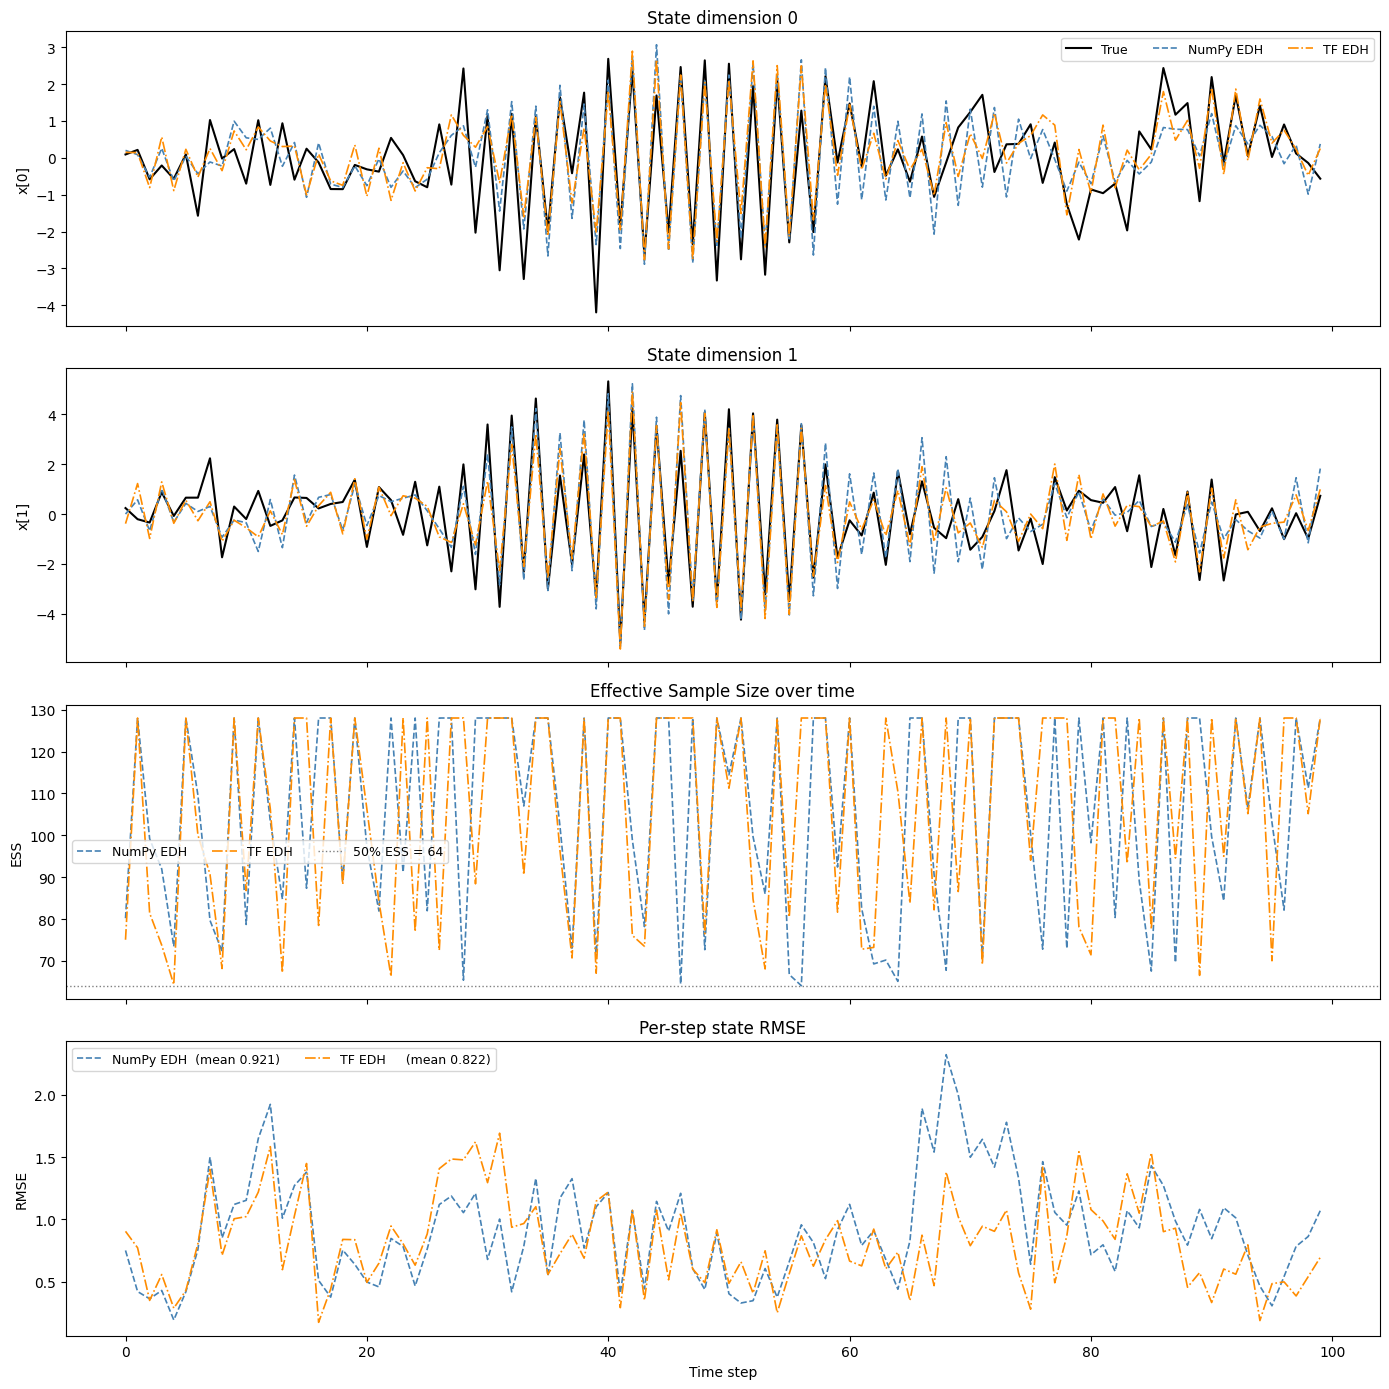


Summary
  Mean RMSE   NumPy EDH : 0.9214
  Mean RMSE   TF    EDH : 0.8217
  Mean ESS    NumPy EDH : 105.6 / 128
  Mean ESS    TF    EDH : 106.4 / 128


In [14]:
rmse_np  = np.sqrt(np.mean((means_np  - X_true)**2, axis=1))
rmse_tf  = np.sqrt(np.mean((means_tf  - X_true)**2, axis=1))
# rmse_ledh= np.sqrt(np.mean((means_ledh- X_true)**2, axis=1))

t_axis = np.arange(T_DEMO)

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# ── State dim 0 ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(t_axis, X_true[:, 0], "k-", lw=1.5, label="True")
ax.plot(t_axis, means_np[:, 0],  "--", lw=1.2, color="steelblue",  label="NumPy EDH")
ax.plot(t_axis, means_tf[:, 0],  "-.", lw=1.2, color="darkorange", label="TF EDH")
# ax.plot(t_axis, means_ledh[:, 0], ":", lw=1.2, color="green",       label="TF LEDH")
ax.set_ylabel("x[0]"); ax.legend(ncol=4, fontsize=9); ax.set_title("State dimension 0")

# ── State dim 1 ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(t_axis, X_true[:, 1], "k-", lw=1.5)
ax.plot(t_axis, means_np[:, 1],  "--", lw=1.2, color="steelblue")
ax.plot(t_axis, means_tf[:, 1],  "-.", lw=1.2, color="darkorange")
# ax.plot(t_axis, means_ledh[:, 1], ":", lw=1.2, color="green")
ax.set_ylabel("x[1]"); ax.set_title("State dimension 1")

# ── ESS over time ─────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(t_axis, ess_np,   "--", lw=1.2, color="steelblue",  label="NumPy EDH")
ax.plot(t_axis, ess_tf,   "-.", lw=1.2, color="darkorange", label="TF EDH")
# ax.plot(t_axis, ess_ledh, ":",  lw=1.2, color="green",       label="TF LEDH")
ax.axhline(0.5 * N_PART, ls=":", color="gray", lw=1, label=f"50% ESS = {0.5*N_PART:.0f}")
ax.set_ylabel("ESS"); ax.set_title("Effective Sample Size over time")
ax.legend(ncol=4, fontsize=9)

# ── Per-step RMSE ─────────────────────────────────────────────────────────────
ax = axes[3]
ax.plot(t_axis, rmse_np,   "--", lw=1.2, color="steelblue",  label=f"NumPy EDH  (mean {rmse_np.mean():.3f})")
ax.plot(t_axis, rmse_tf,   "-.", lw=1.2, color="darkorange", label=f"TF EDH     (mean {rmse_tf.mean():.3f})")
# ax.plot(t_axis, rmse_ledh, ":",  lw=1.2, color="green",       label=f"TF LEDH    (mean {rmse_ledh.mean():.3f})")
ax.set_xlabel("Time step"); ax.set_ylabel("RMSE")
ax.set_title("Per-step state RMSE")
ax.legend(ncol=3, fontsize=9)

plt.tight_layout()
plt.savefig("filter_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nSummary")
print(f"  Mean RMSE   NumPy EDH : {rmse_np.mean():.4f}")
print(f"  Mean RMSE   TF    EDH : {rmse_tf.mean():.4f}")
# print(f"  Mean RMSE   TF   LEDH : {rmse_ledh.mean():.4f}")
print(f"  Mean ESS    NumPy EDH : {ess_np.mean():.1f} / {N_PART}")
print(f"  Mean ESS    TF    EDH : {ess_tf.mean():.1f} / {N_PART}")
# print(f"  Mean ESS    TF   LEDH : {ess_ledh.mean():.1f} / {N_PART}")